<a href="https://colab.research.google.com/github/fourmodern/cellvit-tutorial/blob/main/01_CellViT_tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CellViT 튜토리얼: 하나의 모델로 수행하는 5가지 task

**CellViT** (Hörst et al., *Medical Image Analysis* 2024)는 H&E 이미지에서 세포핵을 **찾고 → 분할하고 → 분류하는** Vision Transformer 기반 모델입니다.

```
              ┌─ [CLS] token ─────────────► ① 조직 타입 분류 (19종)
  H&E 패치 ─► ViT Encoder ─┬─ NP decoder ─► ② 세포핵 / 배경 (binary)
  (1024²)     (SAM-H or    ├─ HV decoder ─► ③ 수평·수직 거리맵 → 붙은 핵 분리
              HIPT-256)    └─ NT decoder ─► ④ 픽셀별 세포 타입 (PanNuke 5종)
                    │
                    └─ patch tokens ────────► ⑤ 세포별 임베딩 (후속 분석용)
```

| # | Task | 출력 | 이 노트북 섹션 |
|---|---|---|---|
| 1 | 조직 타입 분류 | 패치당 19개 조직 확률 | §3 |
| 2 | 세포핵 검출 | 세포 중심 좌표 | §5 |
| 3 | 세포핵 인스턴스 분할 | 세포별 윤곽(contour) | §5 |
| 4 | 세포핵 분류 | Neoplastic / Inflammatory / Connective / Dead / Epithelial | §6 |
| 5 | 세포 임베딩 추출 | 세포당 1280차원(SAM-H) 벡터 | §7 |

> WSI 전체 추론, 분류기 교체, 나만의 분류기 학습은 `02_CellViT_plusplus.ipynb`에서 다룹니다.

**참고**: 모델은 **40x (≈0.25 µm/px)** H&E로 학습되었습니다. 코드/가중치 라이선스는 Apache 2.0 + **Commons Clause**(상업적 이용 제한)입니다.

## 0. 환경 설정

**Colab 사용 시**
1. 메뉴 `런타임 → 런타임 유형 변경 → T4 GPU` 선택
2. 아래 설치 셀을 실행하면 패키지 설치 후 **런타임이 자동으로 재시작**됩니다 (cellvit이 `numpy<2`를 요구하기 때문).
3. 재시작 후 **처음부터 다시 실행**하세요. 설치 셀은 자동으로 건너뜁니다.

로컬 Jupyter에서는 `pip install cellvit openslide-bin umap-learn`이 된 커널이면 설치 셀이 아무것도 하지 않습니다.

In [1]:
# 0-1. 설치 (Colab에서 최초 1회)
import sys, os, importlib.util

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and importlib.util.find_spec("cellvit") is None:
    !apt-get -qq install -y openslide-tools > /dev/null
    !pip -q install cellvit openslide-bin umap-learn
    print("설치 완료 → 런타임을 재시작합니다. 재시작 후 처음부터 다시 실행하세요.")
    os.kill(os.getpid(), 9)  # Colab 런타임 재시작

In [2]:
# 0-2. 경로와 옵션
from pathlib import Path

WORKDIR = Path("/content/cellvit_tutorial") if IN_COLAB else Path.cwd()
WORKDIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)
# 로컬 venv 커널에서도 cellvit-* CLI를 찾도록 현재 파이썬의 bin 경로를 PATH 앞에 추가
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]

# 모델 가중치(SAM-H 약 2.8GB)를 Google Drive에 캐시하면 다음 세션에서 재다운로드하지 않습니다.
USE_DRIVE_CACHE = False
if IN_COLAB and USE_DRIVE_CACHE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.environ["CELLVIT_CACHE"] = "/content/drive/MyDrive/cellvit_cache"
else:
    os.environ["CELLVIT_CACHE"] = str(WORKDIR / "models")  # cellvit import 전에 설정해야 함

# "SAM"  : CellViT-SAM-H  (논문 최고 성능, encoder = SAM ViT-H, embedding 1280차원)
# "HIPT" : CellViT-256    (encoder = HIPT ViT-S/16, embedding 384차원, 가볍고 빠름)
MODEL_NAME = "SAM"
print("WORKDIR:", WORKDIR, "| CACHE:", os.environ["CELLVIT_CACHE"], "| MODEL:", MODEL_NAME)

WORKDIR: /home/hjpark/dp/cellvit_tutorial | CACHE: /home/hjpark/dp/cellvit_tutorial/models | MODEL: SAM


In [3]:
# 모델 가중치 + 예제 WSI 다운로드 (Zenodo, 처음 한 번만)
from cellvit.utils.cache_models import cache_cellvit_sam_h, cache_cellvit_256
from cellvit.utils.cache_test_database import cache_test_database

CKPT_PATH = cache_cellvit_sam_h() if MODEL_NAME == "SAM" else cache_cellvit_256()
cache_test_database(run_dir=str(WORKDIR))  # → WORKDIR/test_database (x40_svs, x20_svs, BRACS, ...)

!ls -lh {CKPT_PATH}
!ls test_database/*

The file CellViT-SAM-H-x40-AMP.pth already exists in /home/hjpark/dp/cellvit_tutorial/models.
-rw-rw-r-- 1 hjpark hjpark 2.7G 10월  5 15:03 /home/hjpark/dp/cellvit_tutorial/models/CellViT-SAM-H-x40-AMP.pth
test_database/filelist.csv

test_database/BRACS:
BRACS_1640_N_3_cropped.tiff

test_database/Philips:
Philips-1.tiff

test_database/x20_svs:
CMU-1-Small-Region.svs

test_database/x40_svs:
JP2K-33003-2.svs


In [4]:
# 공통 유틸 함수
import json, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import cv2
import matplotlib.pyplot as plt
import openslide

from cellvit.utils.tools import unflatten_dict
from cellvit.models.cell_segmentation.cellvit_sam import CellViTSAM
from cellvit.models.cell_segmentation.cellvit_256 import CellViT256

warnings.filterwarnings("ignore")

# 한글 폰트: 시스템에 NanumGothic이 없으면 Google Fonts에서 받아 등록
import matplotlib.font_manager as fm, urllib.request
_font = WORKDIR / "NanumGothic-Regular.ttf"
if not _font.exists():
    urllib.request.urlretrieve("https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf", _font)
fm.fontManager.addfont(str(_font))
plt.rcParams["font.family"] = fm.FontProperties(fname=str(_font)).get_name()
plt.rcParams["axes.unicode_minus"] = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_cellvit(ckpt_path, device=DEVICE):
    """CellViT 체크포인트 → (model, config). cellvit.inference.CellViTInference._load_model과 동일한 방식."""
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    conf = unflatten_dict(ckpt["config"], ".")
    common = dict(
        num_nuclei_classes=conf["data"]["num_nuclei_classes"],
        num_tissue_classes=conf["data"]["num_tissue_classes"],
        regression_loss=conf["model"].get("regression_loss", False),
    )
    if ckpt["arch"] == "CellViTSAM":
        model = CellViTSAM(model_path=None, vit_structure=conf["model"]["backbone"], **common)
    else:
        model = CellViT256(model256_path=None, **common)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.eval().to(device), conf


def to_tensor(img, conf):
    """RGB uint8 (H, W, 3) → 정규화된 (1, 3, H, W) 텐서"""
    norm = conf["transformations"].get("normalize", {})
    mean = np.array(norm.get("mean", (0.5, 0.5, 0.5)))
    std = np.array(norm.get("std", (0.5, 0.5, 0.5)))
    x = (img / 255.0 - mean) / std
    return torch.from_numpy(x.transpose(2, 0, 1)).float()[None]


@torch.inference_mode()
def run_cellvit(model, conf, img):
    """패치 하나에 대해 forward. H, W는 16의 배수여야 함 (40x, 0.25 µm/px 기준)."""
    x = to_tensor(img, conf).to(DEVICE)
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=DEVICE == "cuda"):
        out = model(x, retrieve_tokens=True)
    return {k: v.float().cpu() for k, v in out.items()}


def postprocess(model, out, magnification=40):
    """NP/HV/NT 맵 → (instance map, 세포 리스트). 배경(type 0)으로 분류된 인스턴스는 제외."""
    pred = {
        "nuclei_binary_map": F.softmax(out["nuclei_binary_map"], dim=1),
        "nuclei_type_map": F.softmax(out["nuclei_type_map"], dim=1),
        "hv_map": out["hv_map"],
    }
    inst_map, cell_dicts = model.calculate_instance_map(pred, magnification=magnification)
    cells = [dict(c, id=int(i)) for i, c in cell_dicts[0].items() if c["type"] != 0]
    return inst_map[0].numpy().astype(np.int32), cells


def cell_embeddings(tokens, cells, token_size=16):
    """세포 bbox가 덮는 ViT 토큰을 평균 → 세포당 1개 벡터 (CellViT++와 동일한 방식)
    tokens: (D, H/16, W/16), bbox: [[row_min, col_min], [row_max, col_max]]"""
    embs = []
    for c in cells:
        bb = np.asarray(c["bbox"]) / token_size
        r0, c0 = np.floor(bb[0]).astype(int)
        r1, c1 = np.ceil(bb[1]).astype(int)
        embs.append(tokens[:, r0:r1, c0:c1].flatten(1).mean(1))
    return torch.stack(embs) if embs else torch.empty(0, tokens.shape[0])


TARGET_MPP = 0.25  # CellViT 학습 해상도 (40x)


def read_patch_40x(slide, x, y, size=1024):
    """level-0 좌표 (x, y)부터 0.25 µm/px 기준 size×size 패치를 읽음.
    20x(0.5 µm/px) 슬라이드라면 512×512를 읽어 2배 업샘플 → CellViT WSI 파이프라인과 같은 처리."""
    mpp = float(slide.properties.get("openslide.mpp-x", TARGET_MPP))
    scale = mpp / TARGET_MPP
    read = int(round(size / scale))
    im = np.array(slide.read_region((x, y), 0, (read, read)).convert("RGB"))
    if read != size:
        im = cv2.resize(im, (size, size), interpolation=cv2.INTER_CUBIC)
    return im, scale


def draw_cells(img, cells, colors, thickness=2):
    """세포 윤곽을 타입별 색으로 그림. colors: {type_id: (R, G, B)}"""
    canvas = img.copy()
    for c in cells:
        cnt = np.asarray(c["contour"], dtype=np.int32).reshape(-1, 1, 2)
        cv2.drawContours(canvas, [cnt], -1, colors.get(c["type"], (0, 0, 0)), thickness)
    return canvas


def legend(ax, names, colors, **kw):
    from matplotlib.patches import Patch
    handles = [Patch(color=np.array(colors[i]) / 255, label=n) for i, n in names.items() if i in colors]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, **kw)

# 공통 시각화 도구 viz.py: 저장소에 있으면 그대로, 없으면(Colab) GitHub에서 받기
for _d in [WORKDIR, WORKDIR.parent]:
    if (_d / "viz.py").exists():
        sys.path.insert(0, str(_d)); break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/fourmodern/cellvit-tutorial/main/viz.py", WORKDIR / "viz.py")
    sys.path.insert(0, str(WORKDIR))
import viz

print("device:", DEVICE, "| torch", torch.__version__)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0), f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

device: cuda | torch 2.2.2+cu121
NVIDIA GeForce RTX 3090 Ti 23.7 GB


In [5]:
# PanNuke 세포 타입 색상 (CellViT 논문 그림과 동일 계열)
PANNUKE_COLORS = {
    1: (255, 0, 0),     # Neoplastic   - 빨강
    2: (34, 221, 77),   # Inflammatory - 초록
    3: (35, 92, 236),   # Connective   - 파랑
    4: (254, 255, 0),   # Dead         - 노랑
    5: (255, 159, 68),  # Epithelial   - 주황
}

## 1. 모델 불러오기

체크포인트에는 가중치와 함께 학습 설정(`config`)이 들어 있습니다. 여기서 세포 타입·조직 타입 이름과 입력 정규화 값을 꺼내 씁니다.

In [6]:
model, conf = load_cellvit(CKPT_PATH)

NUCLEI_TYPES = {v: k for k, v in conf["dataset_config"]["nuclei_types"].items()}  # {0: "Background", 1: "Neoplastic", ...}
TISSUE_TYPES = {v: k for k, v in conf["dataset_config"]["tissue_types"].items()}

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"아키텍처      : {type(model).__name__}  ({n_params:.0f}M params)")
print(f"임베딩 차원   : {model.embed_dim}")
print(f"세포 타입     : {NUCLEI_TYPES}")
print(f"조직 타입 ({len(TISSUE_TYPES)}) : {list(TISSUE_TYPES.values())}")

아키텍처      : CellViTSAM  (700M params)
임베딩 차원   : 1280
세포 타입     : {0: 'Background', 1: 'Neoplastic', 2: 'Inflammatory', 3: 'Connective', 4: 'Dead', 5: 'Epithelial'}
조직 타입 (19) : ['Adrenal_gland', 'Bile-duct', 'Bladder', 'Breast', 'Cervix', 'Colon', 'Esophagus', 'HeadNeck', 'Kidney', 'Liver', 'Lung', 'Ovarian', 'Pancreatic', 'Prostate', 'Skin', 'Stomach', 'Testis', 'Thyroid', 'Uterus']


## 2. 예제 패치 준비

예제 WSI는 OpenSlide 테스트 데이터의 **피부 조직** (`CMU-1-Small-Region.svs`, Aperio, **20x = 0.5 µm/px**)입니다. 표피(상피)와 진피(결합조직·염증세포)가 함께 있는 영역을 골랐습니다.

CellViT는 **40x (0.25 µm/px)** 로 학습되었으므로, 20x 슬라이드는 512×512를 읽어 **2배 업샘플**한 1024×1024를 넣습니다. (`cellvit-inference`도 내부에서 똑같이 리샘플링합니다.)

> 내 슬라이드로 바꾸려면 `WSI_PATH`와 좌표 `X0, Y0`만 바꾸면 됩니다.

슬라이드 크기 (level 0): (2220, 2967) | mpp: 0.499 | 배율: 20
원본 513×513 px 읽음 → ×2.0 업샘플 → 입력 (1024, 1024, 3)


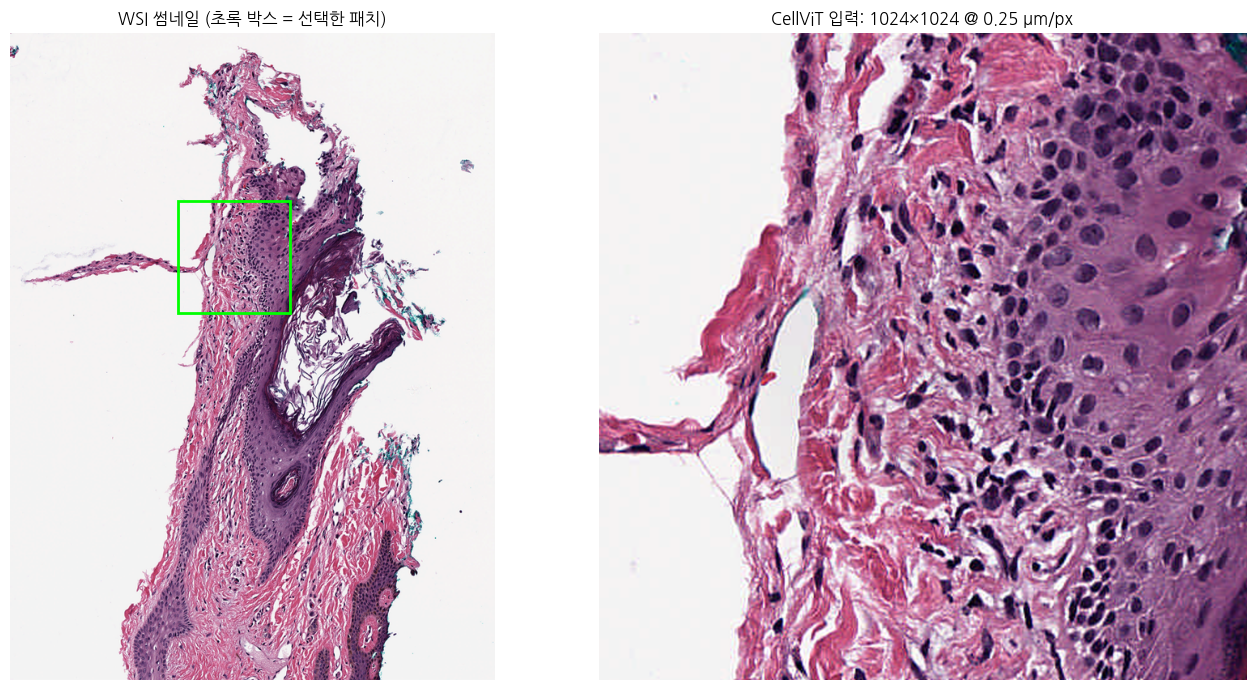

In [7]:
WSI_PATH = WORKDIR / "test_database/x20_svs/CMU-1-Small-Region.svs"
X0, Y0 = 768, 768  # level-0(20x) 좌표: 표피-진피 경계

slide = openslide.OpenSlide(str(WSI_PATH))
print("슬라이드 크기 (level 0):", slide.dimensions, "| mpp:", slide.properties.get("openslide.mpp-x"),
      "| 배율:", slide.properties.get("openslide.objective-power"))

img, scale = read_patch_40x(slide, X0, Y0, 1024)
src = 1024 / scale  # 원본 슬라이드에서 읽은 크기
print(f"원본 {src:.0f}×{src:.0f} px 읽음 → ×{scale:.1f} 업샘플 → 입력 {img.shape}")

thumb = np.array(slide.get_thumbnail((800, 800)).convert("RGB"))
ds = slide.dimensions[0] / thumb.shape[1]
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(thumb)
ax[0].add_patch(plt.Rectangle((X0 / ds, Y0 / ds), src / ds, src / ds, fill=False, ec="lime", lw=2))
ax[0].set_title("WSI 썸네일 (초록 박스 = 선택한 패치)")
ax[1].imshow(img)
ax[1].set_title("CellViT 입력: 1024×1024 @ 0.25 µm/px")
[a.axis("off") for a in ax]
plt.tight_layout(); plt.show()

### 추론: forward 한 번으로 모든 출력 얻기

`retrieve_tokens=True`를 주면 디코더 출력과 함께 encoder 마지막 층의 patch token도 받습니다.

In [8]:
t = time.time()
out = run_cellvit(model, conf, img)
print(f"추론 시간: {time.time() - t:.2f}s\n")
for k, v in out.items():
    print(f"{k:20s} {tuple(v.shape)}")

추론 시간: 1.33s

tissue_types         (1, 19)
nuclei_binary_map    (1, 2, 1024, 1024)
hv_map               (1, 2, 1024, 1024)
nuclei_type_map      (1, 6, 1024, 1024)
tokens               (1, 1280, 64, 64)


## 3. Task ① 조직 타입 분류

ViT의 `[CLS]` 토큰 위에 붙은 linear head가 PanNuke의 19개 조직 중 하나를 예측합니다. 학습 시 보조(auxiliary) task로 쓰인 출력이라 정밀한 조직 분류기로 쓰기보다는 **품질 확인용**으로 보는 게 좋습니다.

> 이 예제에서는 실제 조직이 **피부(Skin)** 인데 Skin을 상위권에 올리지 못합니다. 1024px 패치 하나만 보는 데다 20x를 업샘플한 입력이라 문맥이 부족하기 때문입니다. 조직 타입이 중요하면 슬라이드 메타데이터나 별도의 조직 분류 모델을 쓰세요.

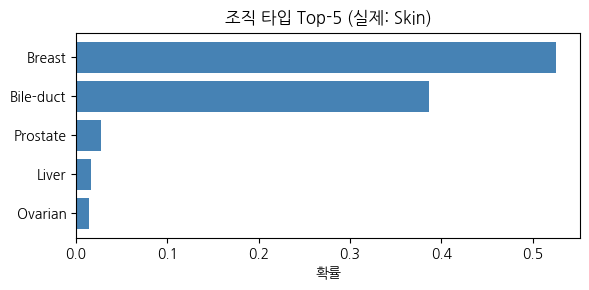

In [9]:
prob = F.softmax(out["tissue_types"][0], dim=0).numpy()
top = np.argsort(prob)[::-1][:5]

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh([TISSUE_TYPES[i] for i in top][::-1], prob[top][::-1], color="steelblue")
ax.set_xlabel("확률"); ax.set_title("조직 타입 Top-5 (실제: Skin)")
plt.tight_layout(); plt.show()

## 4. 세 디코더의 원시 출력 살펴보기

CellViT는 HoVer-Net과 같은 3갈래 디코더 구조를 씁니다.

- **NP (Nuclei Pixel)**: 픽셀이 세포핵일 확률
- **HV (Horizontal-Vertical)**: 각 픽셀에서 자기 세포핵 중심까지의 수평/수직 거리(−1~1). 핵 경계에서 값이 급변하므로 **붙어 있는 핵을 떼어내는** 단서가 됩니다.
- **NT (Nuclei Type)**: 픽셀별 세포 타입 확률

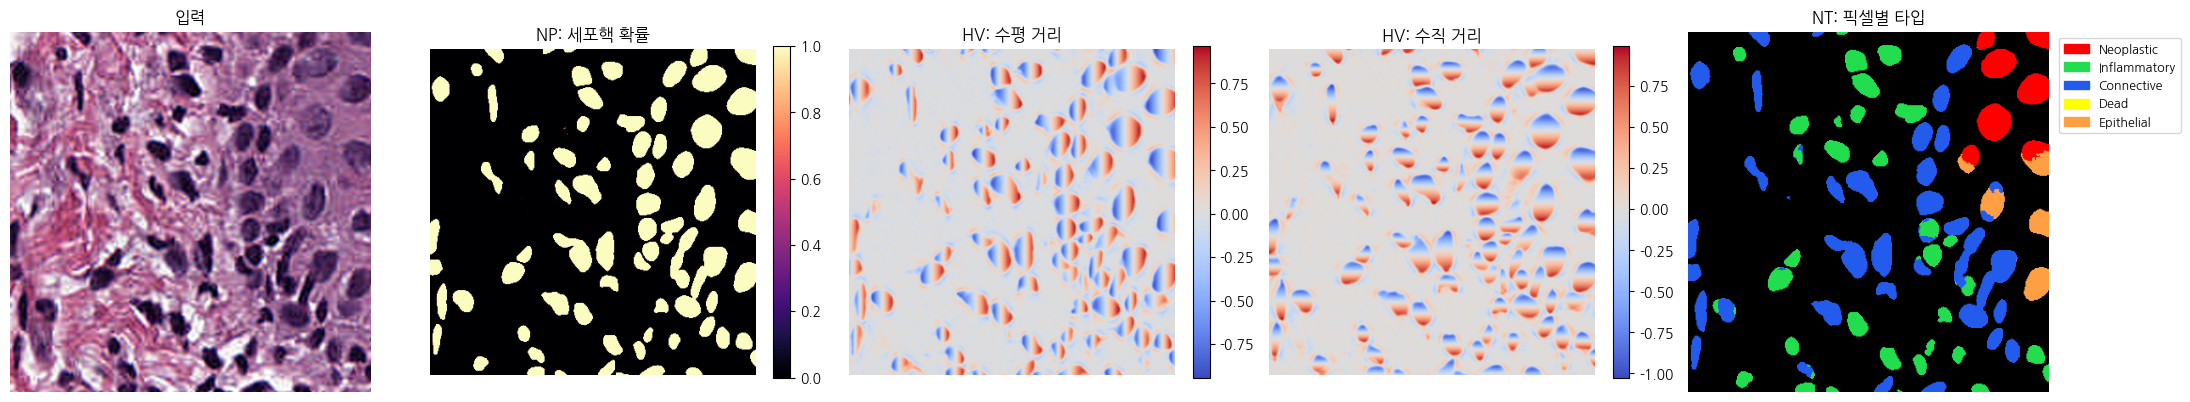

In [10]:
np_prob = F.softmax(out["nuclei_binary_map"], 1)[0, 1].numpy()
hv = out["hv_map"][0].numpy()
nt = out["nuclei_type_map"][0].argmax(0).numpy()

nt_rgb = np.zeros((*nt.shape, 3), np.uint8)
for t, col in PANNUKE_COLORS.items():
    nt_rgb[nt == t] = col

crop = (slice(320, 704), slice(400, 784))  # 세포가 많은 영역 확대
fig, ax = plt.subplots(1, 5, figsize=(22, 4.8))
panels = [(img[crop], "입력", None), (np_prob[crop], "NP: 세포핵 확률", "magma"),
          (hv[0][crop], "HV: 수평 거리", "coolwarm"), (hv[1][crop], "HV: 수직 거리", "coolwarm"),
          (nt_rgb[crop], "NT: 픽셀별 타입", None)]
for a, (im, title, cmap) in zip(ax, panels):
    h = a.imshow(im, cmap=cmap)
    a.set_title(title); a.axis("off")
    if cmap: plt.colorbar(h, ax=a, fraction=0.046)
legend(ax[-1], NUCLEI_TYPES, PANNUKE_COLORS)
plt.tight_layout(); plt.show()

## 5. Task ②③ 세포핵 검출 + 인스턴스 분할

NP와 HV 맵을 watershed 기반 후처리로 합쳐 **세포핵마다 고유 ID**를 붙입니다. 결과는 세포별로 `centroid`(중심), `contour`(윤곽), `bbox`, `type`, `type_prob`을 가진 딕셔너리입니다.

검출된 세포핵: 297개
예시: {'bbox': [[0, 310], [35, 333]], 'centroid': [320.8, 16.1], 'contour': '38 points', 'type_prob': 1.0, 'type': 3, 'id': 1}


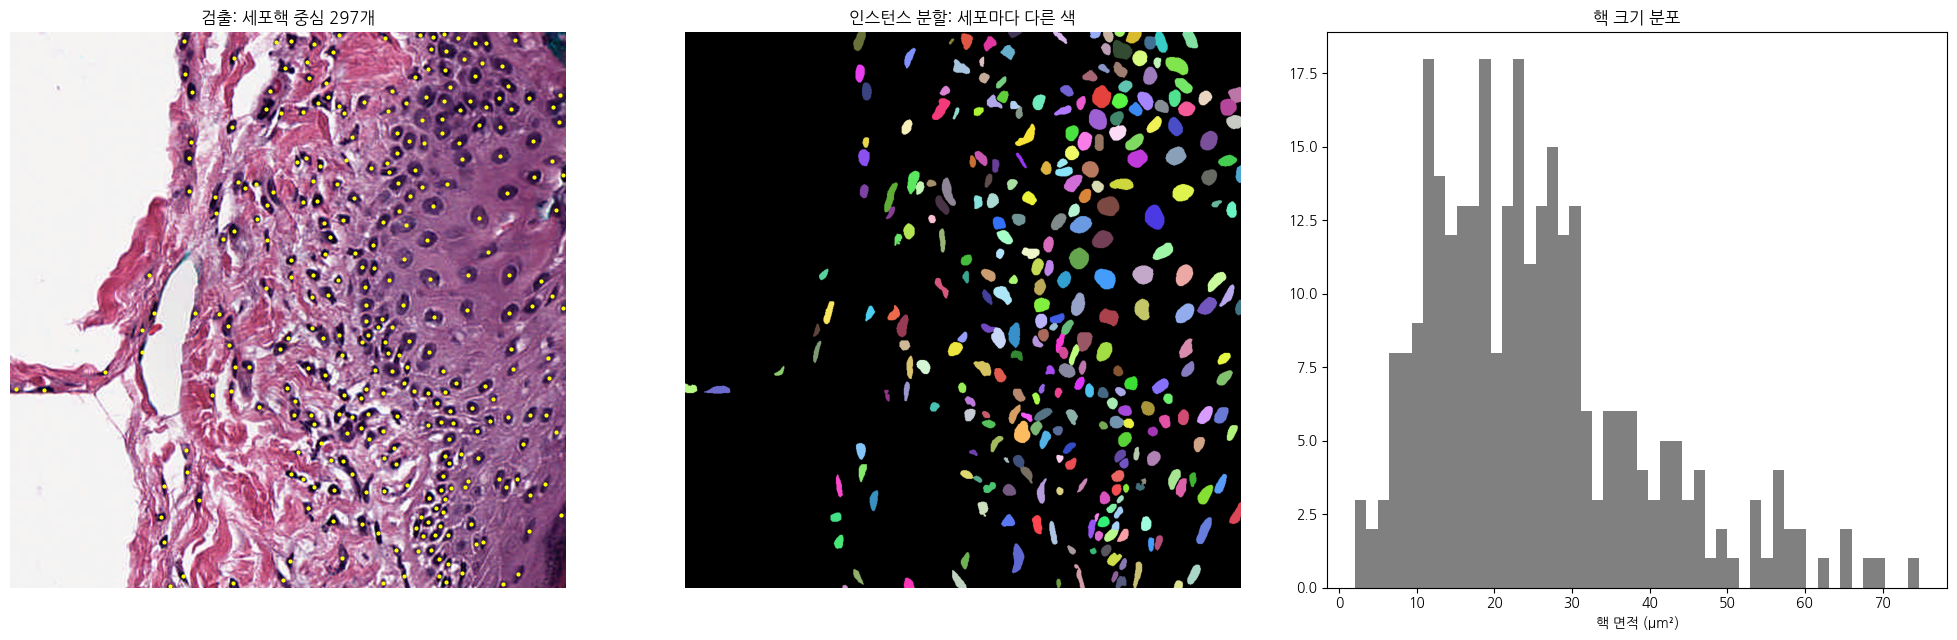

In [11]:
inst_map, cells = postprocess(model, out, magnification=40)
print(f"검출된 세포핵: {len(cells)}개")
print("예시:", {k: (np.round(v, 1).tolist() if k != "contour" else f"{len(v)} points") for k, v in cells[0].items()})

rng = np.random.default_rng(0)
lut = rng.integers(50, 255, (inst_map.max() + 1, 3)).astype(np.uint8); lut[0] = 0
centroids = np.array([c["centroid"] for c in cells])
areas = np.array([cv2.contourArea(np.asarray(c['contour'], np.int32)) for c in cells]) * 0.25**2  # µm²

fig, ax = plt.subplots(1, 3, figsize=(20, 6.5))
ax[0].imshow(img); ax[0].scatter(centroids[:, 0], centroids[:, 1], s=4, c="yellow")
ax[0].set_title(f"검출: 세포핵 중심 {len(cells)}개")
ax[1].imshow(lut[inst_map]); ax[1].set_title("인스턴스 분할: 세포마다 다른 색")
[a.axis("off") for a in ax[:2]]
ax[2].hist(areas, bins=50, color="gray"); ax[2].set_xlabel("핵 면적 (µm²)"); ax[2].set_title("핵 크기 분포")
plt.tight_layout(); plt.show()

## 6. Task ④ 세포핵 분류 (PanNuke 5종)

각 세포의 타입은 그 세포 영역 안의 NT 픽셀 예측을 **다수결**로 정합니다. `type_prob`은 다수결 타입이 차지한 픽셀 비율입니다.

> **관찰 포인트**: 정상 피부인데도 표피 기저층 세포 일부가 `Neoplastic`(빨강)으로 나옵니다. PanNuke는 종양 조직 위주로 구성돼 있어 크고 진한 상피 핵을 종양으로 보는 경향이 있습니다. 이런 도메인 차이 때문에 CellViT++에서 분류기를 데이터에 맞게 바꾸는 기능이 중요해집니다.

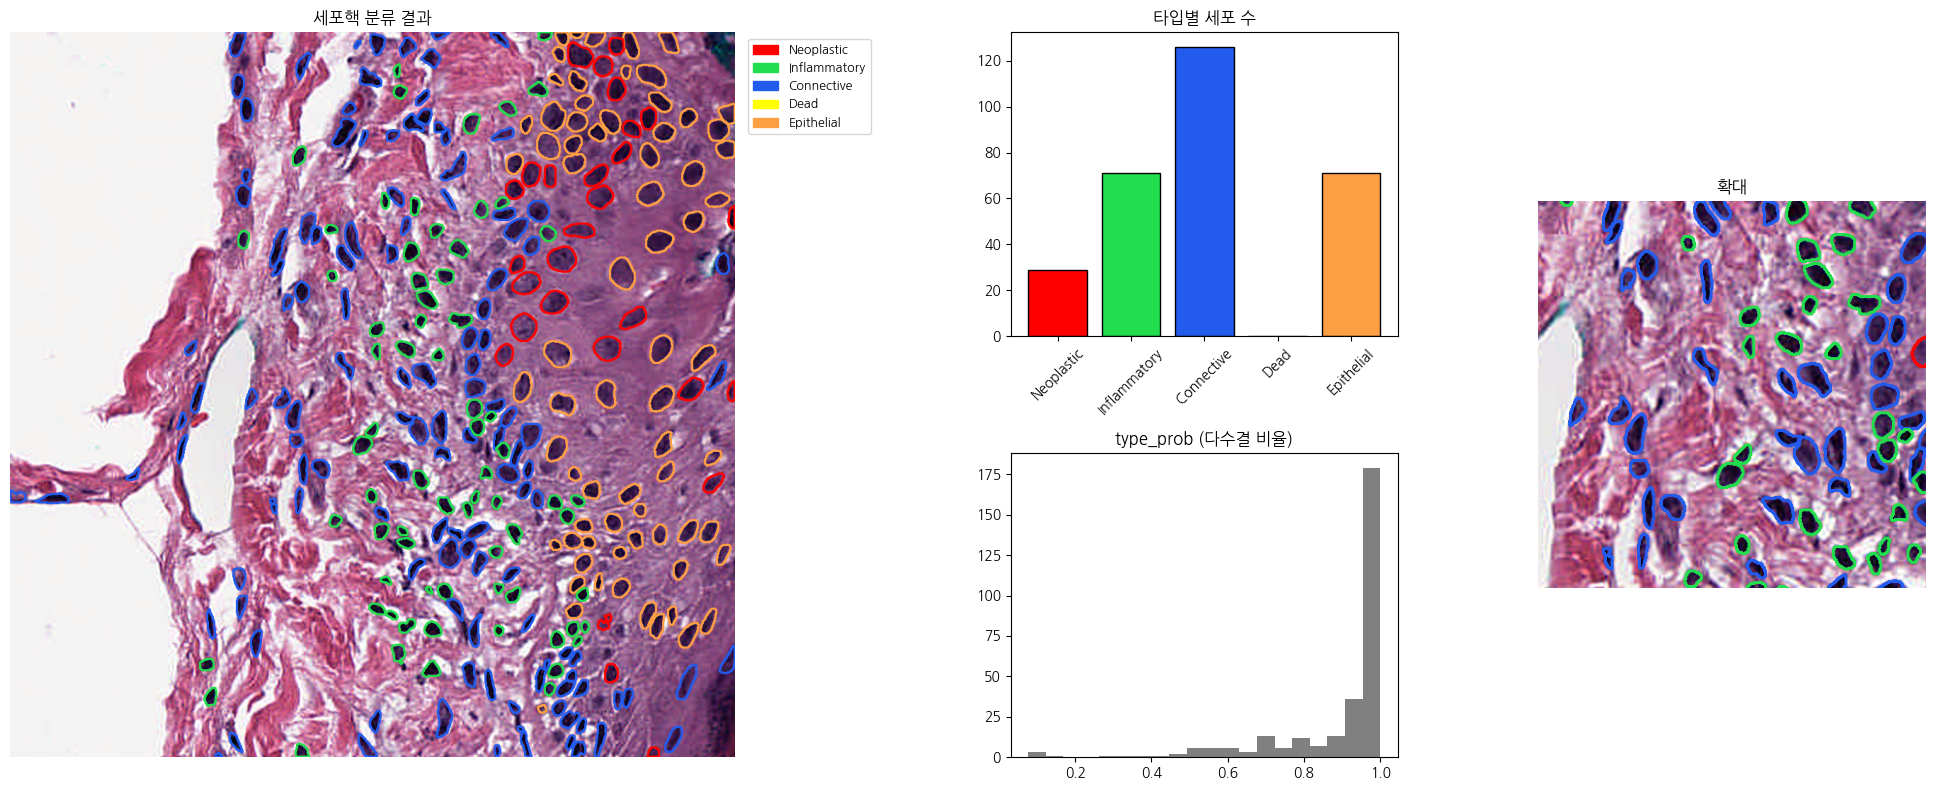

Neoplastic        29  (9.8%)
Inflammatory      71  (23.9%)
Connective       126  (42.4%)
Dead               0  (0.0%)
Epithelial        71  (23.9%)


In [12]:
overlay = draw_cells(img, cells, PANNUKE_COLORS)
types = np.array([c["type"] for c in cells])
type_prob = np.array([c["type_prob"] for c in cells])

fig = plt.figure(figsize=(20, 8))
ax0 = fig.add_subplot(1, 2, 1); ax0.imshow(overlay); ax0.axis("off")
ax0.set_title("세포핵 분류 결과"); legend(ax0, NUCLEI_TYPES, PANNUKE_COLORS)

ax1 = fig.add_subplot(2, 4, 3)
ids = sorted(PANNUKE_COLORS)
counts = [(types == i).sum() for i in ids]
ax1.bar([NUCLEI_TYPES[i] for i in ids], counts, color=[np.array(PANNUKE_COLORS[i]) / 255 for i in ids], ec="k")
ax1.set_title("타입별 세포 수"); ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(2, 4, 7)
ax2.hist(type_prob, bins=20, color="gray"); ax2.set_title("type_prob (다수결 비율)")

zoom = (slice(300, 700), slice(300, 700))
ax3 = fig.add_subplot(1, 4, 4); ax3.imshow(overlay[zoom]); ax3.axis("off"); ax3.set_title("확대")
plt.tight_layout(); plt.show()

for i, n in zip(ids, counts):
    print(f"{NUCLEI_TYPES[i]:14s} {n:5d}  ({n / len(cells):.1%})")

### 6-0. 타입별 분포 대시보드

타입별 세포 수·비율과 함께, 타입마다 **모델 확신도(`type_prob`)** 와 **핵 면적** 분포를 바이올린으로 봅니다.

- `type_prob` = 핵 안의 픽셀 중 다수결 타입이 차지한 비율. 1에 가까울수록 모델이 망설임 없이 판정한 세포입니다.
- 이 예제에는 정답 라벨이 없으므로 **정확도는 계산할 수 없습니다.** 확신도가 낮은 타입은 결과를 더 조심해서 해석하세요. (정답이 있을 때의 정확도 그래프는 02 노트북 Part 4에 있습니다)

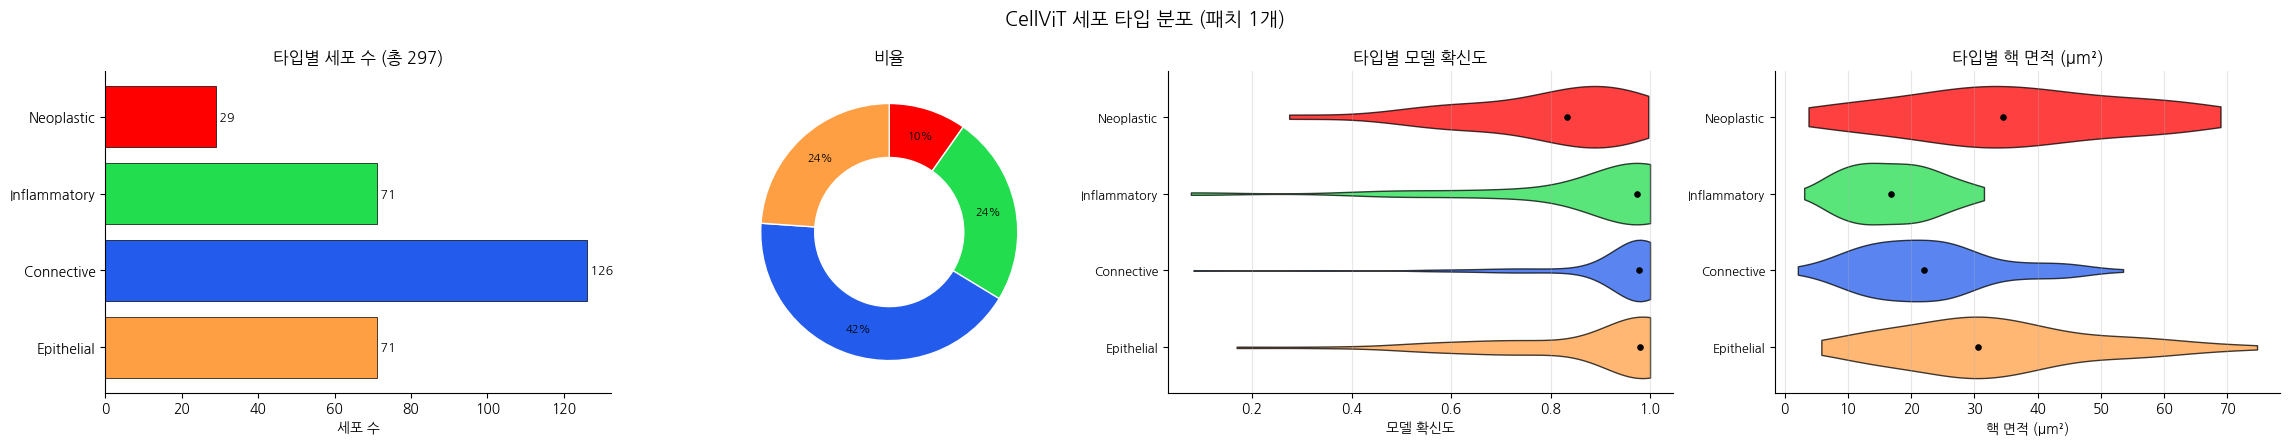

In [13]:
cell_df = pd.DataFrame({
    "type": [NUCLEI_TYPES[c["type"]] for c in cells],
    "type_prob": [c["type_prob"] for c in cells],
    "area_um2": [cv2.contourArea(np.asarray(c["contour"], np.float32)) * 0.25 ** 2 for c in cells],
})
viz.type_summary(cell_df, "type", {NUCLEI_TYPES[k]: PANNUKE_COLORS[k] for k in PANNUKE_COLORS},
                 order=[NUCLEI_TYPES[k] for k in PANNUKE_COLORS],
                 value_cols={"type_prob": "모델 확신도", "area_um2": "핵 면적 (µm²)"},
                 title="CellViT 세포 타입 분포 (패치 1개)")

### 6-1. 조직 사진과 나란히 보기

예측을 믿기 전에 **조직 사진을 직접 보는 것**이 가장 중요합니다. 같은 영역을 원본 H&E, 윤곽선, 반투명 채움으로 나란히 놓았습니다.

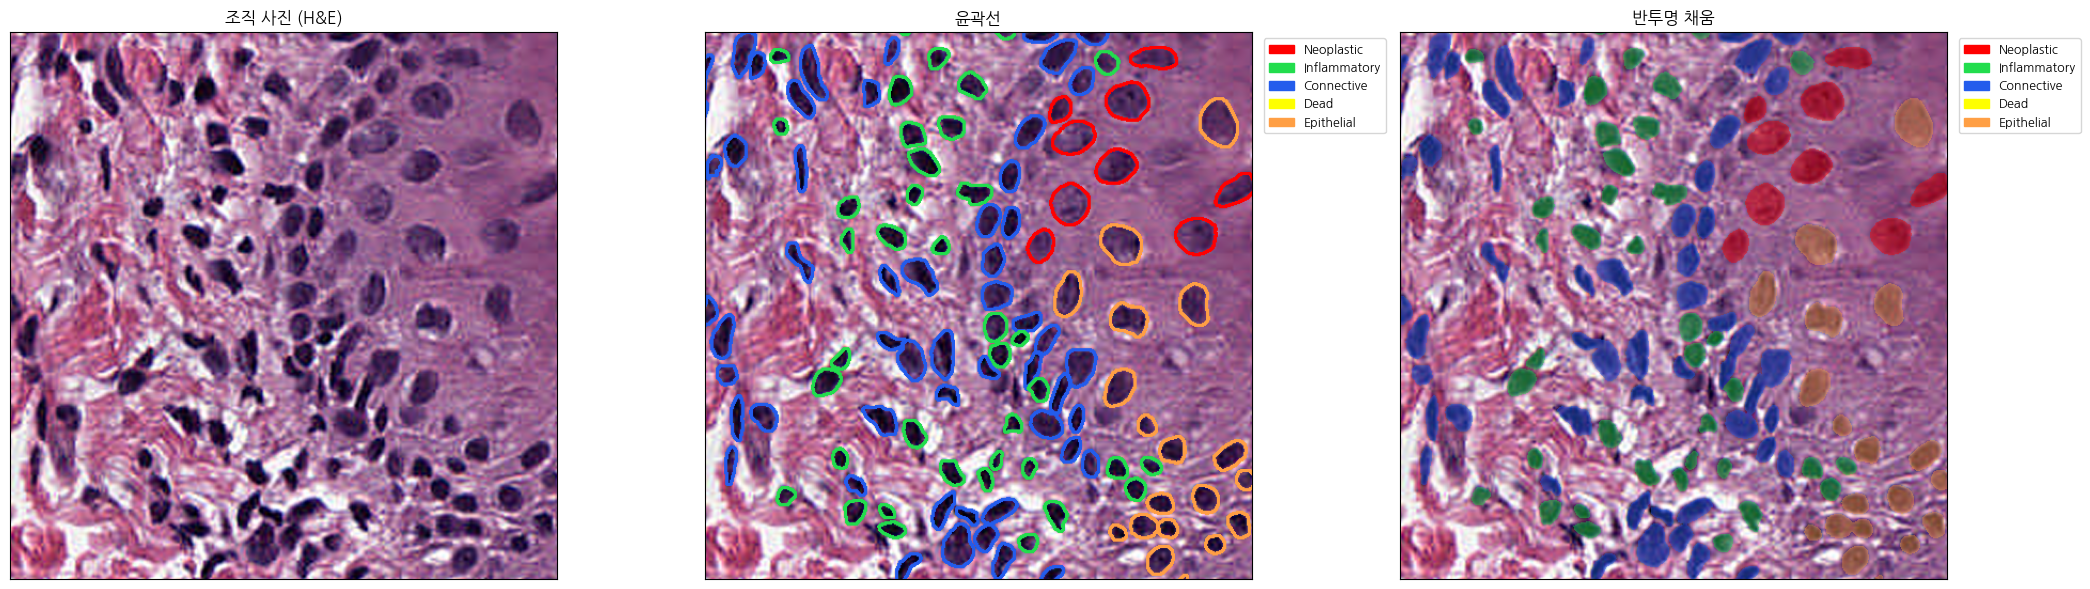

In [14]:
pan_color = lambda c: PANNUKE_COLORS[c["type"]]
pan_label = lambda c: NUCLEI_TYPES[c["type"]]
pan_items = [(NUCLEI_TYPES[k], PANNUKE_COLORS[k]) for k in PANNUKE_COLORS]

viz.side_by_side(img, [
    ("윤곽선", viz.overlay(img, cells, pan_color, mode="contour"), pan_items),
    ("반투명 채움", viz.overlay(img, cells, pan_color, mode="fill", alpha=0.45), pan_items),
], crop=(slice(256, 768), slice(384, 896)))

### 6-2. 인터랙티브 뷰어

- **마우스 휠**로 확대, **드래그**로 이동, **더블클릭**으로 원래 크기
- 세포 위에 마우스를 올리면 타입·확률·핵 면적
- 오른쪽 **범례를 클릭**하면 그 타입을 숨기고, **더블클릭**하면 그 타입만 봅니다

> 인터랙티브 그림은 Colab/Jupyter에서 보입니다(GitHub 미리보기에서는 보이지 않음).

In [15]:
hover = lambda c: (f"<b>{NUCLEI_TYPES[c['type']]}</b><br>type_prob {c['type_prob']:.2f}"
                   f"<br>핵 면적 {cv2.contourArea(np.asarray(c['contour'], np.float32)) * 0.25 ** 2:.0f} µm²")
viz.interactive(img, cells, pan_color, pan_label, hover_of=hover, order=[NUCLEI_TYPES[k] for k in PANNUKE_COLORS],
                title="CellViT 세포 분류 (PanNuke) — 휠로 확대, 범례 클릭으로 타입 켜고 끄기")

### 6-3. 타입별 세포 갤러리

각 타입으로 분류된 세포를 무작위로 잘라 모았습니다. 같은 줄의 세포들이 **형태적으로 비슷한지**, 다른 줄과 구분되는지를 보면 분류가 그럴듯한지 빠르게 판단할 수 있습니다.

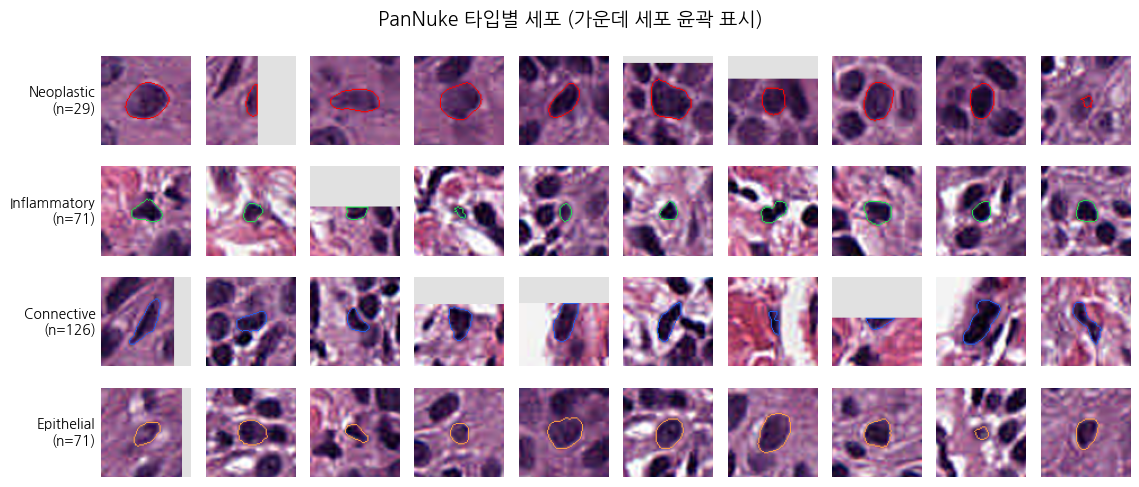

In [16]:
viz.cell_gallery(cells, pan_label, pan_color, order=[NUCLEI_TYPES[k] for k in PANNUKE_COLORS], img=img, n=10, size=80,
                 title="PanNuke 타입별 세포 (가운데 세포 윤곽 표시)")

## 7. Task ⑤ 세포 임베딩 추출

encoder 마지막 층의 patch token(16×16 px당 1개) 중 **세포 bbox가 덮는 토큰을 평균**하면 세포당 하나의 벡터가 됩니다. 이 임베딩이 CellViT++에서 분류기를 교체할 때의 입력이고, 세포 그래프(GNN)나 공간 분석의 feature로도 쓸 수 있습니다.

아래 UMAP에서 PanNuke 타입별로 군집이 나뉘면, 임베딩이 세포 형태 정보를 담고 있다는 뜻입니다.

토큰 그리드: (1280, 64, 64) → 세포 임베딩: (297, 1280)


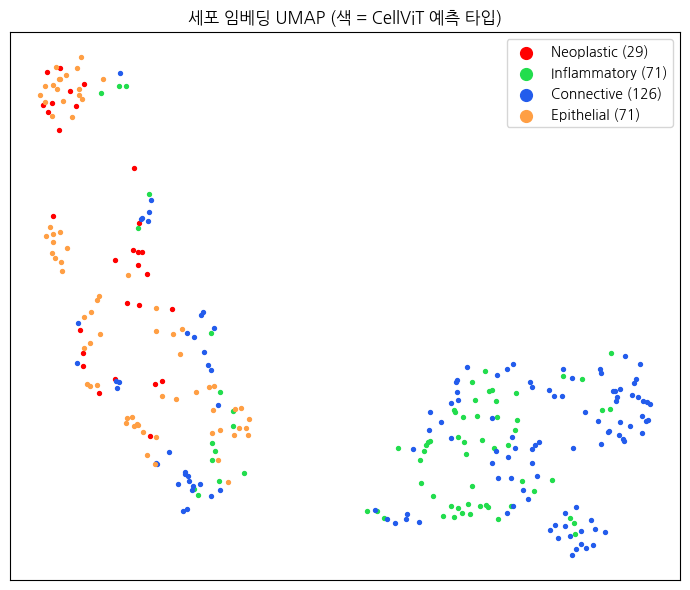

In [17]:
tokens = out["tokens"][0]  # (D, 64, 64)
emb = cell_embeddings(tokens, cells).numpy()
print("토큰 그리드:", tuple(tokens.shape), "→ 세포 임베딩:", emb.shape)

import umap
xy = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(emb)

fig, ax = plt.subplots(figsize=(7, 6))
for t in ids:
    m = types == t
    if m.any():
        ax.scatter(xy[m, 0], xy[m, 1], s=8, color=np.array(PANNUKE_COLORS[t]) / 255, label=f"{NUCLEI_TYPES[t]} ({m.sum()})")
ax.legend(markerscale=3); ax.set_title("세포 임베딩 UMAP (색 = CellViT 예측 타입)"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 8. 결과 내보내기: QuPath용 GeoJSON

세포 윤곽을 **슬라이드 좌표**(패치 오프셋 더함)로 바꿔 GeoJSON으로 저장하면 QuPath에서 `File → Import objects`로 원본 WSI 위에 겹쳐 볼 수 있습니다. (WSI 전체에 대해서는 `cellvit-inference --geojson`이 같은 일을 해 줍니다 → 02 노트북)

In [18]:
features = []
for c in cells:
    poly = (np.asarray(c["contour"]) / scale + [X0, Y0]).tolist()  # 40x 패치 좌표 → 슬라이드 level-0 좌표
    poly.append(poly[0])  # 폴리곤 닫기
    name = NUCLEI_TYPES[c["type"]]
    features.append({
        "type": "Feature",
        "geometry": {"type": "Polygon", "coordinates": [poly]},
        "properties": {"objectType": "detection",
                       "classification": {"name": name, "color": list(PANNUKE_COLORS[c["type"]])}},
    })

out_path = WORKDIR / "outputs" / "patch_cells.geojson"
out_path.parent.mkdir(exist_ok=True)
out_path.write_text(json.dumps({"type": "FeatureCollection", "features": features}))
print(f"{len(features)}개 세포 → {out_path}")

297개 세포 → /home/hjpark/dp/cellvit_tutorial/outputs/patch_cells.geojson


## 정리

| Task | 사용한 출력 | 핵심 코드 |
|---|---|---|
| 조직 분류 | `out["tissue_types"]` | softmax |
| 검출 + 분할 | `nuclei_binary_map` + `hv_map` | `model.calculate_instance_map()` |
| 세포 분류 | `nuclei_type_map` | 세포 영역 내 다수결 |
| 세포 임베딩 | `out["tokens"]` | bbox 내 토큰 평균 |

**한계**
- 분류 체계가 PanNuke 5종으로 **고정**됨 (림프구/형질세포/대식세포 등 구분 불가)
- 새 체계로 바꾸려면 원래는 픽셀 단위 마스크 라벨로 전체 재학습이 필요

→ 이 한계를 푸는 것이 **CellViT++** 입니다. `02_CellViT_plusplus.ipynb`로 이어집니다.